# TECH 405 – Week 2: Exploratory Data Analysis

## Smart Attendance System – Face Recognition

**Student: Amit**

The self-collected student face dataset is now available under `dataset/`. This notebook calculates the EDA results from the files at run time and excludes GUI assets in `collage_images/`.

In [16]:
from pathlib import Path
import hashlib
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

DATASET_DIR = Path("dataset")
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

def discover_images(root=DATASET_DIR):
    """Find supported images without ever scanning the GUI asset directory."""
    root = Path(root)
    if not root.exists() or not root.is_dir():
        return []
    return sorted(p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS)

def class_from_path(path, root=DATASET_DIR):
    try:
        relative = Path(path).relative_to(root)
        return relative.parts[0] if len(relative.parts) > 1 else ""
    except ValueError:
        return ""

image_paths = discover_images()
dataset_available = DATASET_DIR.exists() and bool(image_paths)
if not dataset_available:
    print("Dataset has not been collected yet. Add student face images to the dataset/ directory to populate this section.")

## 1. Dataset Card

- **Dataset name:** Smart Attendance System – Student Face Dataset
- **Source:** Self-collected for the TECH 405 Smart Attendance System project
- **Source link:** Not applicable – self-collected dataset
- **Licence:** Private academic dataset; not publicly licensed
- **Data type:** Grayscale student face images
- **Task:** Student face identification / recognition for automated attendance
- **Target:** Student identity
- **Current enrolled identities:** The current collection contains five student folders (calculated and verified below).
- **Size on disk, number of samples, and number of classes:** Calculated automatically below.

Observed current properties include five represented identities and a relatively small academic dataset. Possible risks include limited environmental diversity, similar collection conditions, lighting or pose bias, and limited generalization to unseen students. Privacy and informed-consent requirements remain important. These are limitations and risks to consider; equal image counts do not guarantee equal image quality or recognition difficulty.

In [17]:
def format_bytes(n):
    units = ["B", "KB", "MB", "GB"]
    value = float(n)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f"{value:.2f} {unit}"
        value /= 1024

if image_paths:
    total_bytes = sum(p.stat().st_size for p in image_paths)
    classes = sorted({class_from_path(p) for p in image_paths if class_from_path(p)})
    card = pd.DataFrame({"Metric": ["Size on disk", "Number of samples", "Number of classes/students"],
                         "Value": [format_bytes(total_bytes), len(image_paths), len(classes)]})
    display(card)
else:
    print("Size, sample count, and class count: Pending dataset collection.")

,Metric,Value
0,Size on disk,2.10 MB
1,Number of samples,250
2,Number of classes/students,5


## 2. Data Loading and Initial Inspection

The expected layout is `dataset/student_id/image.ext`. The loader accepts JPG, JPEG, PNG, and WEBP files and records image metadata when Pillow can read it.

In [18]:
records = []
for path in image_paths:
    record = {"filepath": str(path), "filename": path.name, "class_name": class_from_path(path),
              "extension": path.suffix.lower(), "size_bytes": path.stat().st_size,
              "width": np.nan, "height": np.nan, "channels": np.nan, "image_mode": None}
    try:
        with Image.open(path) as img:
            record.update(width=img.width, height=img.height, image_mode=img.mode,
                          channels=len(img.getbands()))
    except (OSError, UnidentifiedImageError):
        pass
    records.append(record)

df = pd.DataFrame(records, columns=["filepath", "filename", "class_name", "extension", "size_bytes", "width", "height", "channels", "image_mode"])
print(f"Dataset shape: {df.shape}")
print(f"Number of classes: {df['class_name'].nunique() if not df.empty else 0}")
print("\nColumn data types:")
display(df.dtypes.to_frame("dtype"))
print("Directory/file structure summary:")
if df.empty:
    print("No supported dataset images found; structure summary is pending dataset collection.")
else:
    display(df.groupby("class_name", dropna=False).size().rename("image_count").to_frame())

Dataset shape: (250, 9)
Number of classes: 5

Column data types:


,dtype
filepath,object
filename,object
class_name,object
extension,object
size_bytes,int64
width,int64
height,int64
channels,int64
image_mode,object


Directory/file structure summary:


,image_count
class_name,
101,50
102,50
103,50
104,50
105,50


Random sample metadata:


,filepath,filename,class_name,extension,size_bytes,width,height,channels,image_mode
142,dataset\103\48.jpg,48.jpg,103,.jpg,8002,200,200,1,L
6,dataset\101\15.jpg,15.jpg,101,.jpg,7736,200,200,1,L
97,dataset\102\7.jpg,7.jpg,102,.jpg,9940,200,200,1,L
60,dataset\102\19.jpg,19.jpg,102,.jpg,10272,200,200,1,L
112,dataset\103\20.jpg,20.jpg,103,.jpg,7658,200,200,1,L


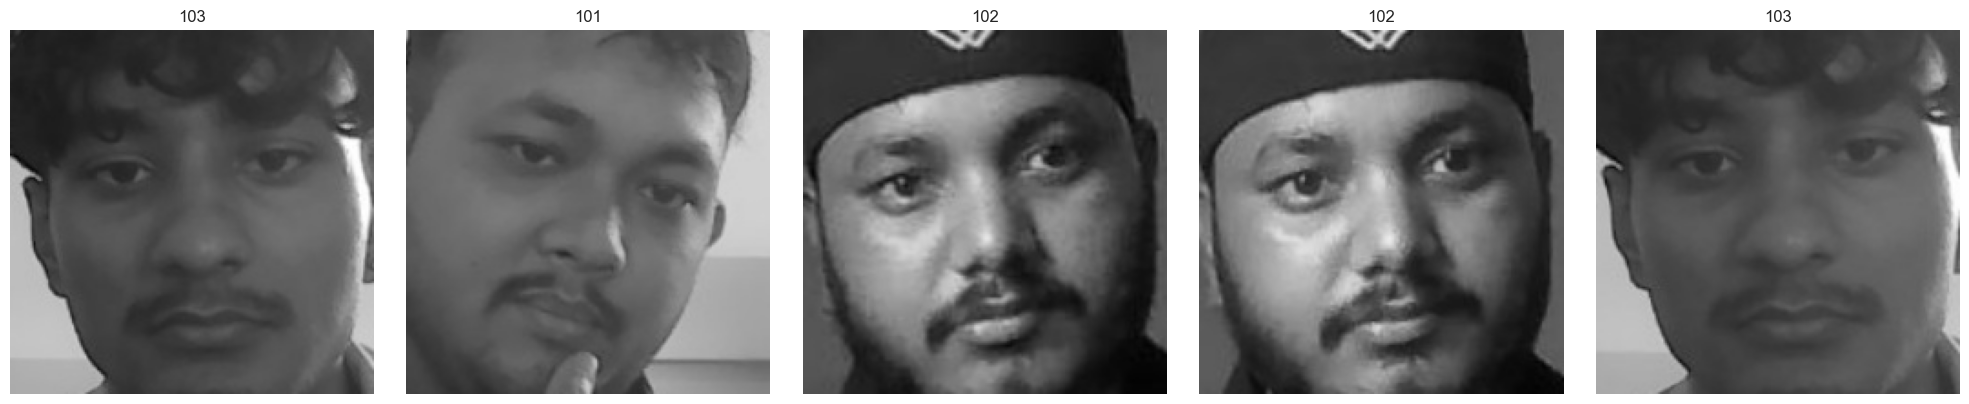

In [19]:
sample = df.sample(n=min(5, len(df)), random_state=RANDOM_STATE) if not df.empty else df
print("Random sample metadata:")
display(sample)
if sample.empty:
    print("Five random samples: Pending dataset collection.")
else:
    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4), squeeze=False)
    for ax, (_, row) in zip(axes[0], sample.iterrows()):
        try:
            with Image.open(row["filepath"]) as img:
                ax.imshow(img.convert("RGB"))
            ax.set_title(row["class_name"] or "Unlabelled")
        except (OSError, UnidentifiedImageError):
            ax.text(0.5, 0.5, "Unreadable image", ha="center", va="center")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## 3. Data Quality Audit

Traditional tabular missing values are not the only concern for image data. This audit checks empty labels/folders, zero-byte files, missing image metadata, unreadable files, and exact duplicate files.

In [20]:
empty_class_labels = int((df["class_name"] == "").sum()) if not df.empty else 0
zero_byte_files = int((df["size_bytes"] == 0).sum()) if not df.empty else 0
missing_metadata = int(df[["width", "height", "channels", "image_mode"]].isna().any(axis=1).sum()) if not df.empty else 0
empty_class_folders = []
if DATASET_DIR.exists():
    empty_class_folders = [str(p) for p in DATASET_DIR.iterdir() if p.is_dir() and not any(q.is_file() and q.suffix.lower() in SUPPORTED_EXTENSIONS for q in p.rglob("*"))]
quality_summary = pd.DataFrame({"Check": ["Missing/empty class labels", "Empty class folders", "Zero-byte files", "Rows with missing image metadata"],
                                 "Count": [empty_class_labels, len(empty_class_folders), zero_byte_files, missing_metadata]})
display(quality_summary)
if empty_class_folders:
    print("Empty class folders:", empty_class_folders)
if df.empty:
    print("Data quality counts are pending dataset collection.")

,Check,Count
0,Missing/empty class labels,0
1,Empty class folders,0
2,Zero-byte files,0
3,Rows with missing image metadata,0


In [21]:
corrupt_rows = []
hash_to_paths = {}
for path in image_paths:
    try:
        with Image.open(path) as img:
            img.verify()
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        hash_to_paths.setdefault(digest, []).append(str(path))
    except (OSError, UnidentifiedImageError, ValueError) as exc:
        corrupt_rows.append({"filepath": str(path), "error": type(exc).__name__})
corrupt_df = pd.DataFrame(corrupt_rows, columns=["filepath", "error"])
duplicate_groups = [paths for paths in hash_to_paths.values() if len(paths) > 1]
duplicate_files = sum(len(paths) - 1 for paths in duplicate_groups)
print(f"Valid images: {len(image_paths) - len(corrupt_df)}")
print(f"Corrupt/unreadable images: {len(corrupt_df)}")
display(corrupt_df if not corrupt_df.empty else pd.DataFrame({"Result": ["No corrupt files found in available data."]}))
print(f"Unique file-content hashes: {len(hash_to_paths)}")
print(f"Duplicate files beyond the first in each exact group: {duplicate_files}")
if duplicate_groups:
    display(pd.DataFrame({"duplicate_group": range(1, len(duplicate_groups) + 1), "paths": duplicate_groups}))
else:
    print("No exact duplicate groups found in available data." if image_paths else "Duplicate analysis is pending dataset collection.")
print("Intended treatment: Corrupt or unreadable images will be excluded from modelling and, where possible, recollected.")
print("Intended treatment: Exact duplicate images will be removed before model training to prevent artificial inflation of the dataset and leakage between data splits.")
print("Perceptual/near-duplicate detection may later be useful for almost identical consecutive webcam frames.")

Valid images: 250
Corrupt/unreadable images: 0


,Result
0,No corrupt files found in available data.


Unique file-content hashes: 250
Duplicate files beyond the first in each exact group: 0
No exact duplicate groups found in available data.
Intended treatment: Corrupt or unreadable images will be excluded from modelling and, where possible, recollected.
Intended treatment: Exact duplicate images will be removed before model training to prevent artificial inflation of the dataset and leakage between data splits.
Perceptual/near-duplicate detection may later be useful for almost identical consecutive webcam frames.


## 4. Class Distribution

The target variable is **student identity**. Counts and interpretation below are computed from the available dataset; no imbalance is assumed before collection.

,image_count
class_name,
101,50
102,50
103,50
104,50
105,50


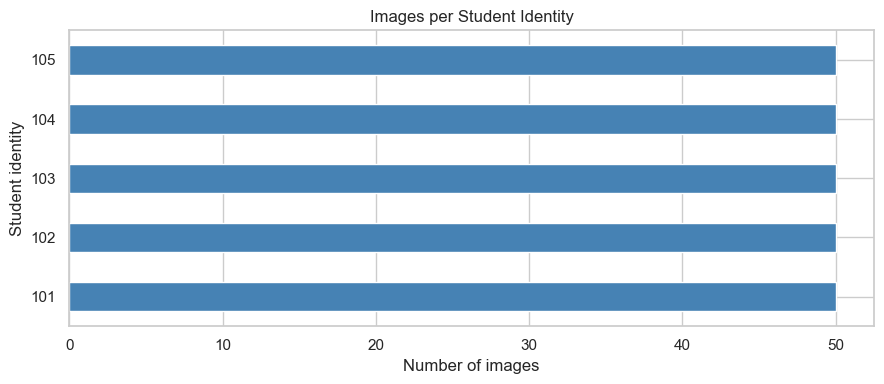

,Statistic,Value
0,Smallest class,50.0
1,Largest class,50.0
2,Mean,50.0
3,Median,50.0
4,Maximum/minimum ratio,1.0


Computed interpretation: the current class counts are perfectly balanced at 50 images per identity.
Imbalance matters because classes with more samples can dominate training, while students with fewer images may have poorer recognition accuracy. Consider similar collection targets, more data for underrepresented students, appropriate augmentation, class weighting, or balanced sampling.


In [22]:
class_counts = df["class_name"].value_counts().sort_values(ascending=True) if not df.empty else pd.Series(dtype="int64", name="image_count")
if class_counts.empty:
    print("Class distribution will be evaluated after face-image collection.")
else:
    display(class_counts.rename("image_count").to_frame())
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(class_counts))))
    class_counts.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Images per Student Identity")
    ax.set_xlabel("Number of images")
    ax.set_ylabel("Student identity")
    plt.tight_layout(); plt.show(); plt.close(fig)
    smallest, largest = class_counts.min(), class_counts.max()
    ratio = largest / smallest if smallest else np.nan
    stats = pd.DataFrame({"Statistic": ["Smallest class", "Largest class", "Mean", "Median", "Maximum/minimum ratio"],
                         "Value": [smallest, largest, class_counts.mean(), class_counts.median(), ratio]})
    display(stats)
    if ratio <= 1.5:
        print(f"Computed interpretation: the current class counts are perfectly balanced at {int(class_counts.iloc[0])} images per identity.")
    else:
        print("Computed interpretation: class sizes show potential imbalance by the 1.5× ratio rule.")
    print("Imbalance matters because classes with more samples can dominate training, while students with fewer images may have poorer recognition accuracy. Consider similar collection targets, more data for underrepresented students, appropriate augmentation, class weighting, or balanced sampling.")

## 5. Train / Validation / Test Split Plan

A starting plan is 70% training, 15% validation, and 15% test, adjusted for the final dataset size. For a closed-set enrolled-student identification system, every student should have sufficient representation in each split.

A naive random image-level split is risky when many images come from one webcam burst: nearly identical frames can appear in training and test, producing unrealistically high accuracy. The preferred approach is session-aware splitting within each student, for example `session_1 → train`, `session_2 → validation`, and `session_3 → test`. Collection should use multiple occasions and vary lighting, head pose, expression, distance, background, and time.

If the future goal changes to recognizing completely unseen identities with a verification/embedding model, evaluation by unseen identities may also be required. For this attendance system, the current assumption is enrolled-student identification.

In [23]:
def session_aware_split(metadata, session_col="session_id", class_col="class_name", seed=RANDOM_STATE):
    """Template: split complete capture sessions within each student.
    Requires one row per image and a session identifier; it does not perform a
    split without session metadata."""
    required = {session_col, class_col}
    missing = required.difference(metadata.columns)
    if missing:
        raise ValueError(f"Missing required metadata columns: {sorted(missing)}")
    rng = np.random.default_rng(seed)
    output = metadata.copy()
    output["split"] = None
    for student, group in output.groupby(class_col):
        sessions = list(group[session_col].dropna().unique())
        rng.shuffle(sessions)
        n = len(sessions)
        boundaries = [max(1, round(0.70*n)), max(1, round(0.85*n))]
        train_sessions, val_sessions = set(sessions[:boundaries[0]]), set(sessions[boundaries[0]:boundaries[1]])
        output.loc[group.index[group[session_col].isin(train_sessions)], "split"] = "train"
        output.loc[group.index[group[session_col].isin(val_sessions)], "split"] = "validation"
        output.loc[group.index[group[session_col].isin(set(sessions) - train_sessions - val_sessions)], "split"] = "test"
    return output

per_student = int(class_counts.iloc[0]) if not class_counts.empty else 0
train_n = round(0.70 * per_student); validation_n = round(0.15 * per_student); test_n = per_student - train_n - validation_n
print(f"Current split example per student: approximately {train_n} training, {validation_n} validation, and {test_n} test images from {per_student} images, following 70/15/15. No artificial split was performed in this notebook.")
print("Use session_aware_split(metadata) after adding a session_id column to the image metadata.")

Current split example per student: approximately 35 training, 8 validation, and 7 test images from 50 images, following 70/15/15. No artificial split was performed in this notebook.
Use session_aware_split(metadata) after adding a session_id column to the image metadata.


## 6. Model-Design Findings

### Findings status

The current dataset supports the following evidence-based model-design findings. These statements are based on the automatically computed EDA results for the present collection and should be revisited if the dataset changes.

- **Finding 1 – Resolution consistency:** All current images are 200 × 200 pixels. A 200 × 200 input is a reasonable initial preprocessing choice; resizing is not currently necessary, avoiding unnecessary interpolation.
- **Finding 2 – Balanced identities:** Each of the five student identities currently contributes 50 images, so class-count imbalance is not a current concern. Equal counts do not guarantee equal image quality, diversity, or recognition difficulty.
- **Finding 3 – Grayscale input:** All current images are grayscale with one channel. A one-channel model input is appropriate where supported; an RGB-only pretrained model would require channel repetition or conversion, and no color information is available.

The notebook continues to calculate these properties rather than relying on hard-coded values.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
width,250.0,NaN,NaN,NaN,200.0,0.0,200.0,200.0,200.0,200.0,200.0
height,250.0,NaN,NaN,NaN,200.0,0.0,200.0,200.0,200.0,200.0,200.0
aspect_ratio,250.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
channels,250.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
image_mode,250,1,L,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN


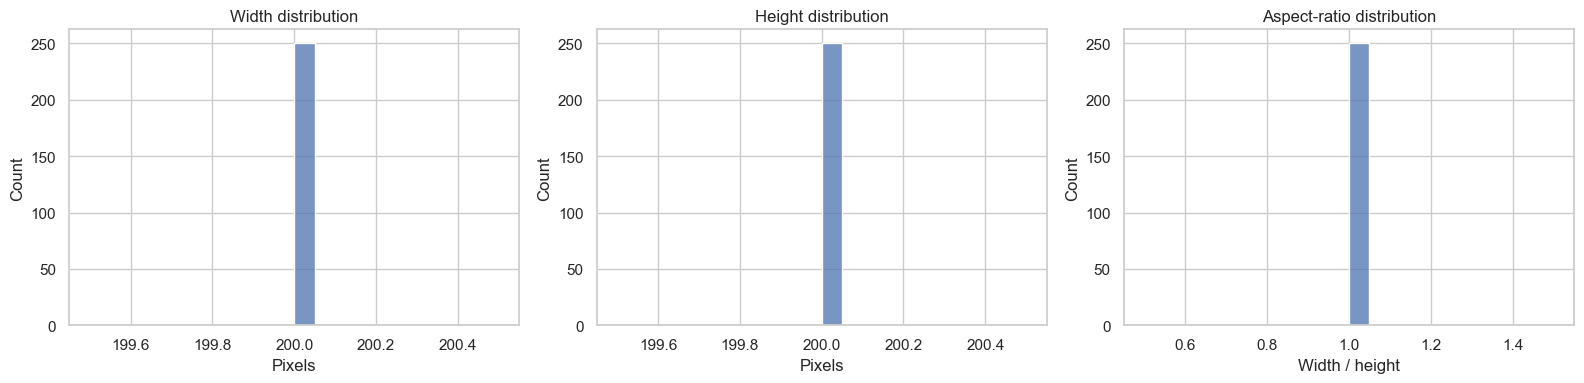

Image modes/channels:


,count
image_mode,
L,250


Computed hook: inspect these distributions before selecting a final target resolution; no resolution is recommended automatically without reviewing the collected data.
Computed evidence hook: no exact duplicates or unreadable metadata were detected in the available files; near-duplicate/session checks still require capture metadata.


In [24]:
if df.empty or df[["width", "height"]].dropna().empty:
    print("Resolution, aspect-ratio, channel, and mode findings are pending dataset collection.")
else:
    dimensions = df.dropna(subset=["width", "height"]).copy()
    dimensions["aspect_ratio"] = dimensions["width"] / dimensions["height"]
    display(dimensions[["width", "height", "aspect_ratio", "channels", "image_mode"]].describe(include="all").T)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.histplot(dimensions["width"], ax=axes[0], bins=20); axes[0].set_title("Width distribution"); axes[0].set_xlabel("Pixels")
    sns.histplot(dimensions["height"], ax=axes[1], bins=20); axes[1].set_title("Height distribution"); axes[1].set_xlabel("Pixels")
    sns.histplot(dimensions["aspect_ratio"], ax=axes[2], bins=20); axes[2].set_title("Aspect-ratio distribution"); axes[2].set_xlabel("Width / height")
    plt.tight_layout(); plt.show(); plt.close(fig)
    print("Image modes/channels:")
    display(dimensions["image_mode"].value_counts(dropna=False).rename("count").to_frame())
    print("Computed hook: inspect these distributions before selecting a final target resolution; no resolution is recommended automatically without reviewing the collected data.")
    if duplicate_files or len(dimensions) != len(df):
        print("Computed evidence hook: duplicate or unreadable-file risk is present and should inform session-aware collection/evaluation.")
    else:
        print("Computed evidence hook: no exact duplicates or unreadable metadata were detected in the available files; near-duplicate/session checks still require capture metadata.")

## One-Page EDA Summary

The Smart Attendance System uses self-collected face images to identify enrolled students for automated attendance. The current dataset contains 250 images across five student identities, with 50 images per class. The class distribution is therefore balanced at the sample-count level.

All current images are JPG files, 200 × 200 pixels, grayscale, and one-channel. The audit found 250 valid images, no corrupt or unreadable files, and no exact duplicate files. These checks remain implemented so future additions are audited automatically.

A 70%/15%/15% plan gives approximately 35 training images and 7–8 validation/test images per student. If images were captured as consecutive frames in one session, a naive image-level split could leak near-identical frames across train and test. Session-aware splitting is preferred; session metadata is not currently recorded, so leakage cannot be claimed to be eliminated.

The current 200 × 200 grayscale format simplifies preprocessing. Future evaluation should still consider capture diversity, lighting, pose, background, privacy, consent, and generalization beyond the five represented identities.

## Part A Completion Checklist

1. Dataset card — completed with current dataset details and automatically calculated metrics.
2. Shape/dtypes/file structure and five random samples — completed from the real dataset.
3. Missing, duplicate, and corrupt audit — completed; current audit found no corrupt or exact duplicate files.
4. Class distribution and imbalance discussion — completed; current sample counts are balanced.
5. Train/validation/test split plan — completed with session-leakage warning.
6. Three evidence-based model-design findings — completed for resolution, identity balance, and grayscale input.

## Part B – Image / Vision

This section analyzes the real student face dataset discovered in Part A. It reuses the existing metadata and excludes GUI assets in `collage_images/`.

### 1. Image Size and Channel Distribution

Image dimensions, aspect ratios, modes, and channel counts are summarized below when valid dataset images are available. These results will help determine preprocessing requirements.


,width,height,aspect_ratio
count,250.0,250.0,250.0
mean,200.0,200.0,1.0
std,0.0,0.0,0.0
min,200.0,200.0,1.0
25%,200.0,200.0,1.0
50%,200.0,200.0,1.0
75%,200.0,200.0,1.0
max,200.0,200.0,1.0


,class_name,filepath,width,height,aspect_ratio,mode,channels
0,101,dataset\101\1.jpg,200,200,1.0,L,1
1,101,dataset\101\10.jpg,200,200,1.0,L,1
2,101,dataset\101\11.jpg,200,200,1.0,L,1
3,101,dataset\101\12.jpg,200,200,1.0,L,1
4,101,dataset\101\13.jpg,200,200,1.0,L,1


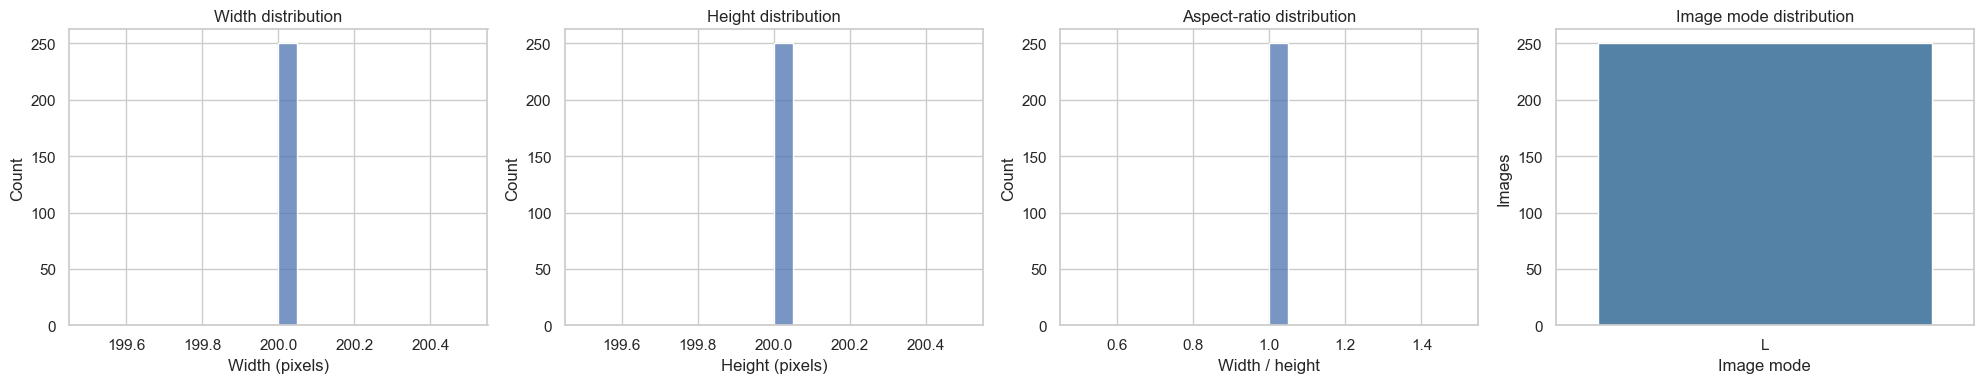

,image_count
channels,
1,250


In [25]:
vision_columns = ["class_name", "filepath", "width", "height", "aspect_ratio", "mode", "channels"]
vision_df = df.copy() if "df" in globals() else pd.DataFrame()
if not vision_df.empty:
    vision_df = vision_df.rename(columns={"image_mode": "mode"})
    for column in vision_columns:
        if column not in vision_df.columns:
            vision_df[column] = np.nan
    vision_df["aspect_ratio"] = vision_df["width"] / vision_df["height"]
    vision_df = vision_df[vision_columns]
    valid_vision_df = vision_df.dropna(subset=["width", "height", "channels"]).copy()
else:
    vision_df = pd.DataFrame(columns=vision_columns)
    valid_vision_df = vision_df.copy()

if valid_vision_df.empty:
    print("Image size and channel analysis is pending dataset collection.")
else:
    display(valid_vision_df[["width", "height", "aspect_ratio"]].describe())
    display(valid_vision_df[vision_columns].head())
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    sns.histplot(valid_vision_df["width"], bins=20, ax=axes[0]); axes[0].set_title("Width distribution"); axes[0].set_xlabel("Width (pixels)")
    sns.histplot(valid_vision_df["height"], bins=20, ax=axes[1]); axes[1].set_title("Height distribution"); axes[1].set_xlabel("Height (pixels)")
    sns.histplot(valid_vision_df["aspect_ratio"], bins=20, ax=axes[2]); axes[2].set_title("Aspect-ratio distribution"); axes[2].set_xlabel("Width / height")
    mode_counts = valid_vision_df["mode"].fillna("Unknown").value_counts()
    sns.barplot(x=mode_counts.index.astype(str), y=mode_counts.values, ax=axes[3], color="steelblue"); axes[3].set_title("Image mode distribution"); axes[3].set_xlabel("Image mode"); axes[3].set_ylabel("Images")
    plt.tight_layout(); plt.show(); plt.close(fig)
    display(valid_vision_df["channels"].value_counts().sort_index().rename("image_count").to_frame())

#### Target Resolution Decision

The final model input resolution must be selected after inspecting the real dimensions, aspect ratios, face detail, computational budget, and whether resizing or aspect-preserving cropping is appropriate. The EDA resolution below is only a decision aid; it is not automatically the final training resolution.


In [26]:
if valid_vision_df.empty:
    print("Final target resolution will be selected after the real face dataset is collected and inspected.")
else:
    dimension_summary = valid_vision_df[["width", "height"]].round().astype(int).mode()
    median_width = int(valid_vision_df["width"].median())
    median_height = int(valid_vision_df["height"].median())
    print(f"Most common width/height values, where available: {dimension_summary.to_dict(orient='records')}")
    print(f"Median dimensions: {median_width} × {median_height} pixels.")
    if (valid_vision_df["width"] == 200).all() and (valid_vision_df["height"] == 200).all():
        print("Evidence-based target resolution: 200 × 200 pixels. All current images already have this size, so resizing is unnecessary and avoidable interpolation can be minimized.")
    else:
        print("Recommendation hook: use a practical, aspect-preserving input size supported by the common dimensions and available face detail; do not stretch images. Review the actual distributions before finalizing it.")

Most common width/height values, where available: [{'width': 200, 'height': 200}]
Median dimensions: 200 × 200 pixels.
Evidence-based target resolution: 200 × 200 pixels. All current images already have this size, so resizing is unnecessary and avoidable interpolation can be minimized.


### 2. Sample Images Per Class

Visual inspection helps identify whether each student has enough variation in lighting, pose, expression, camera distance, background, blur, and occlusion. No dataset-specific visual claim is made until real images are available.


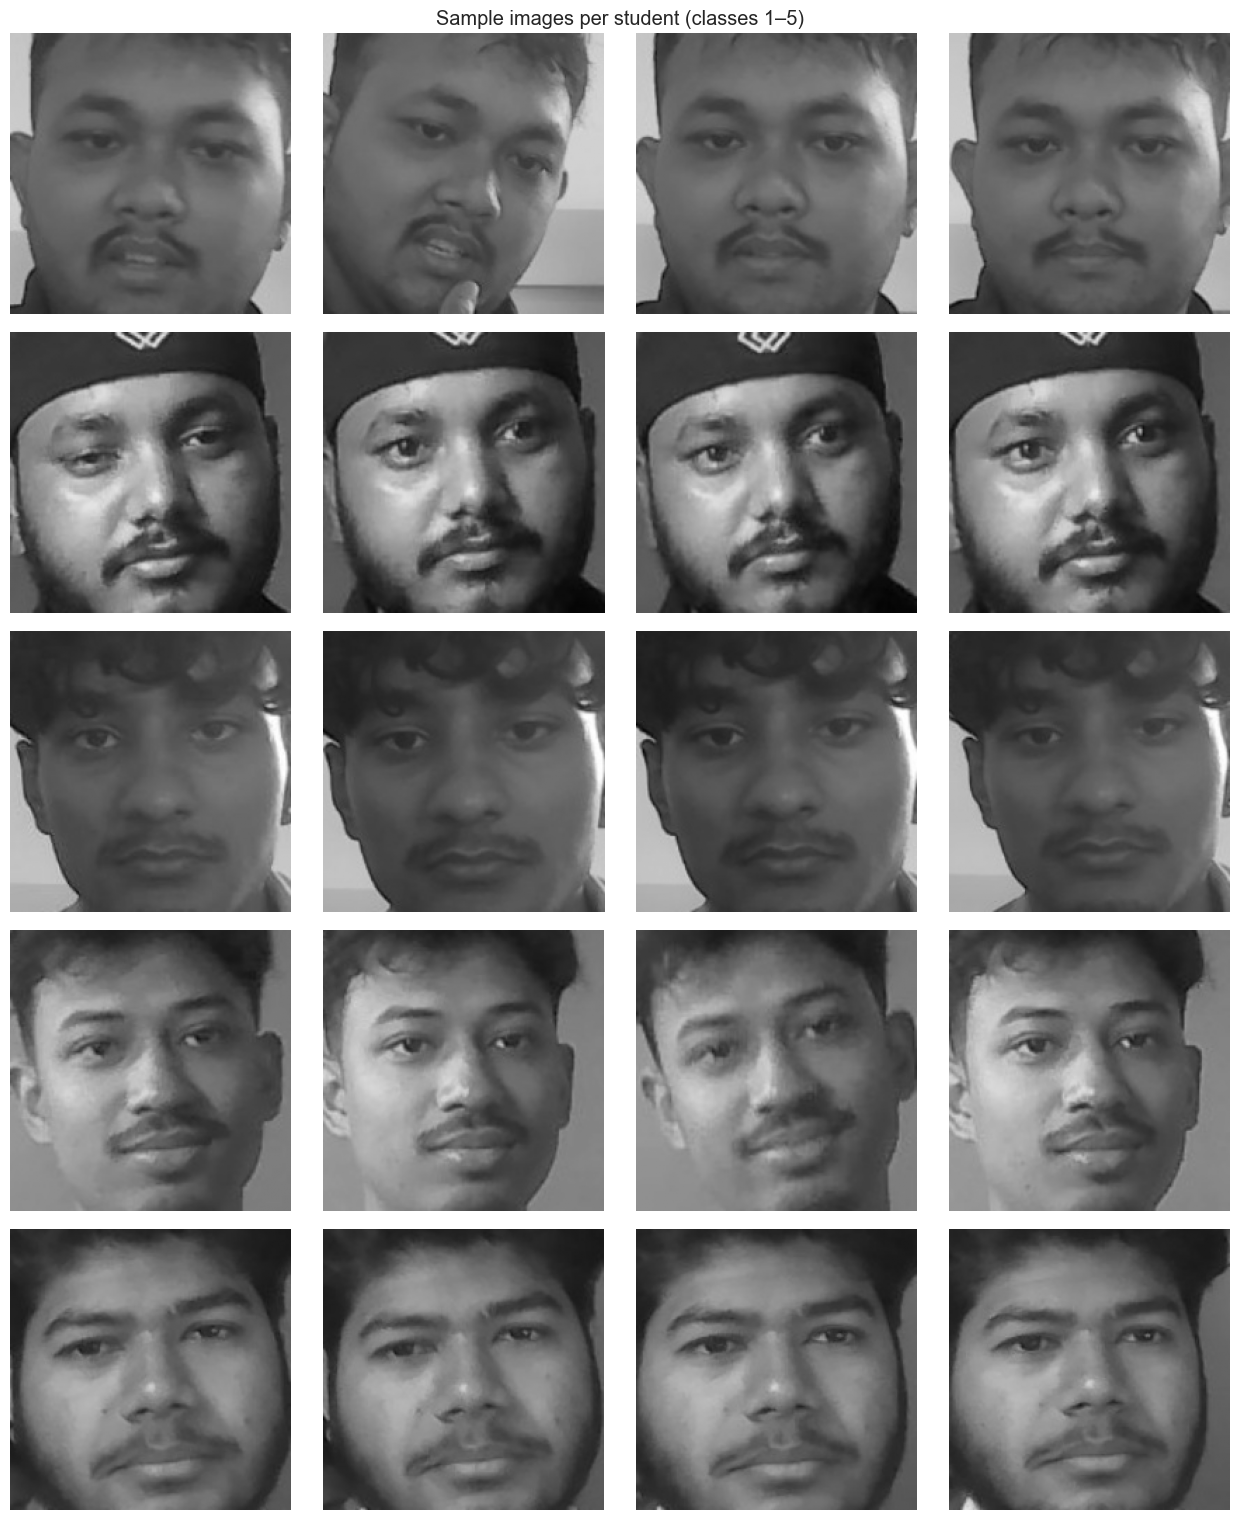

In [27]:
def show_samples_per_class(metadata, samples_per_class=4, classes_per_batch=6, seed=RANDOM_STATE):
    if metadata.empty or "class_name" not in metadata.columns:
        print("Sample grid pending dataset collection.")
        return
    rng = np.random.default_rng(seed)
    class_names = sorted(c for c in metadata["class_name"].dropna().unique() if str(c))
    for batch_start in range(0, len(class_names), classes_per_batch):
        batch = class_names[batch_start:batch_start + classes_per_batch]
        fig, axes = plt.subplots(len(batch), samples_per_class, figsize=(3.2 * samples_per_class, 3.1 * len(batch)), squeeze=False)
        for row_index, class_name in enumerate(batch):
            rows = metadata[metadata["class_name"] == class_name]
            selected = rows.iloc[rng.choice(len(rows), size=min(samples_per_class, len(rows)), replace=False)] if len(rows) else rows
            for col_index, (_, item) in enumerate(selected.iterrows()):
                ax = axes[row_index, col_index]
                try:
                    with Image.open(item["filepath"]) as image:
                        ax.imshow(image, cmap="gray" if image.mode == "L" else None, vmin=0 if image.mode == "L" else None, vmax=255 if image.mode == "L" else None)
                except (OSError, UnidentifiedImageError):
                    ax.text(0.5, 0.5, "Unreadable", ha="center", va="center")
                ax.axis("off")
            axes[row_index, 0].set_ylabel(str(class_name), rotation=0, labelpad=45, va="center")
            for col_index in range(len(selected), samples_per_class):
                axes[row_index, col_index].axis("off")
        fig.suptitle(f"Sample images per student (classes {batch_start + 1}–{batch_start + len(batch)})")
        plt.tight_layout(); plt.show(); plt.close(fig)

show_samples_per_class(vision_df)

### 3. Pixel Intensity Distribution Per Class

For a computationally manageable comparison, each readable image is converted to grayscale and resized to a small analysis size before its intensity values are summarized. Pixel values use a consistent 0–255 range. Differences can motivate later normalization or augmentation, but no issue is claimed without evidence.


,class_name,mean_intensity,std_intensity,min_intensity,max_intensity
0,101,108.328765,37.508379,30,226
1,102,91.105903,49.811062,2,238
2,103,85.202549,39.720782,18,255
3,104,108.289282,42.597589,16,217
4,105,98.044248,38.481852,18,225


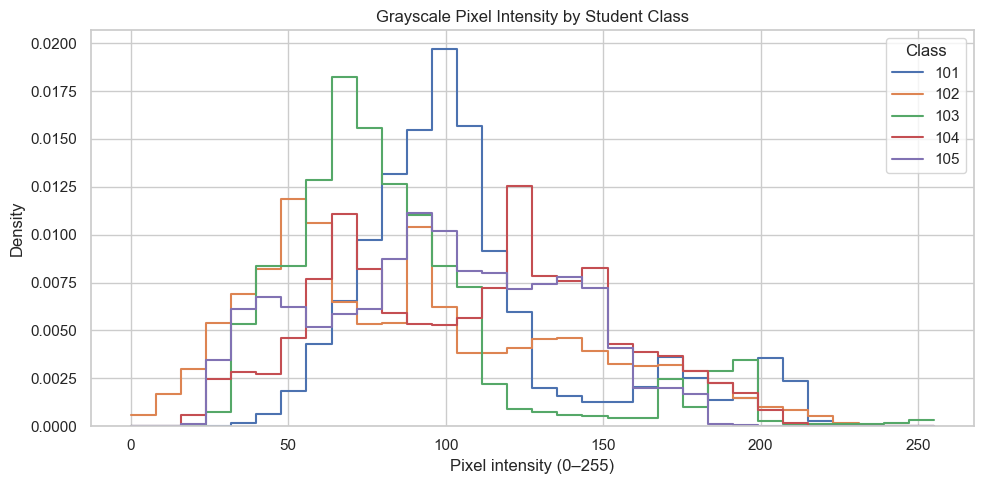

In [28]:
def intensity_statistics_by_class(metadata, max_images_per_class=50, analysis_size=(64, 64), seed=RANDOM_STATE):
    if metadata.empty:
        return pd.DataFrame(columns=["class_name", "mean_intensity", "std_intensity", "min_intensity", "max_intensity"]), {}
    rng = np.random.default_rng(seed)
    stats, values_by_class = [], {}
    for class_name, group in metadata.groupby("class_name"):
        chosen = group.iloc[rng.choice(len(group), size=min(max_images_per_class, len(group)), replace=False)]
        values = []
        for _, item in chosen.iterrows():
            try:
                with Image.open(item["filepath"]) as image:
                    values.append(np.asarray(image.convert("L").resize(analysis_size), dtype=np.uint8).ravel())
            except (OSError, UnidentifiedImageError):
                continue
        if values:
            pixels = np.concatenate(values)
            values_by_class[str(class_name)] = pixels
            stats.append({"class_name": class_name, "mean_intensity": pixels.mean(), "std_intensity": pixels.std(), "min_intensity": pixels.min(), "max_intensity": pixels.max()})
    return pd.DataFrame(stats), values_by_class

intensity_df, intensity_values = intensity_statistics_by_class(vision_df)
if intensity_df.empty:
    print("Pixel intensity analysis pending dataset collection.")
else:
    display(intensity_df)
    class_names = list(intensity_values)
    for start in range(0, len(class_names), 6):
        batch = class_names[start:start + 6]
        fig, ax = plt.subplots(figsize=(10, 5))
        for class_name in batch:
            sns.histplot(intensity_values[class_name], bins=32, binrange=(0, 255), stat="density", element="step", fill=False, label=class_name, ax=ax)
        ax.set_title("Grayscale Pixel Intensity by Student Class")
        ax.set_xlabel("Pixel intensity (0–255)"); ax.set_ylabel("Density"); ax.legend(title="Class")
        plt.tight_layout(); plt.show(); plt.close(fig)

### 4. Mean Image Per Class

A mean image requires equal spatial dimensions. Because face images may differ in size, each readable image is converted to RGB and resized to the fixed EDA-only resolution `MEAN_IMAGE_SIZE = (128, 128)` before pixel-wise averaging. This visualization resolution is not the final training resolution. Mean images can reveal alignment, background, lighting, pose, and variation patterns, but dataset-specific conclusions require real images.


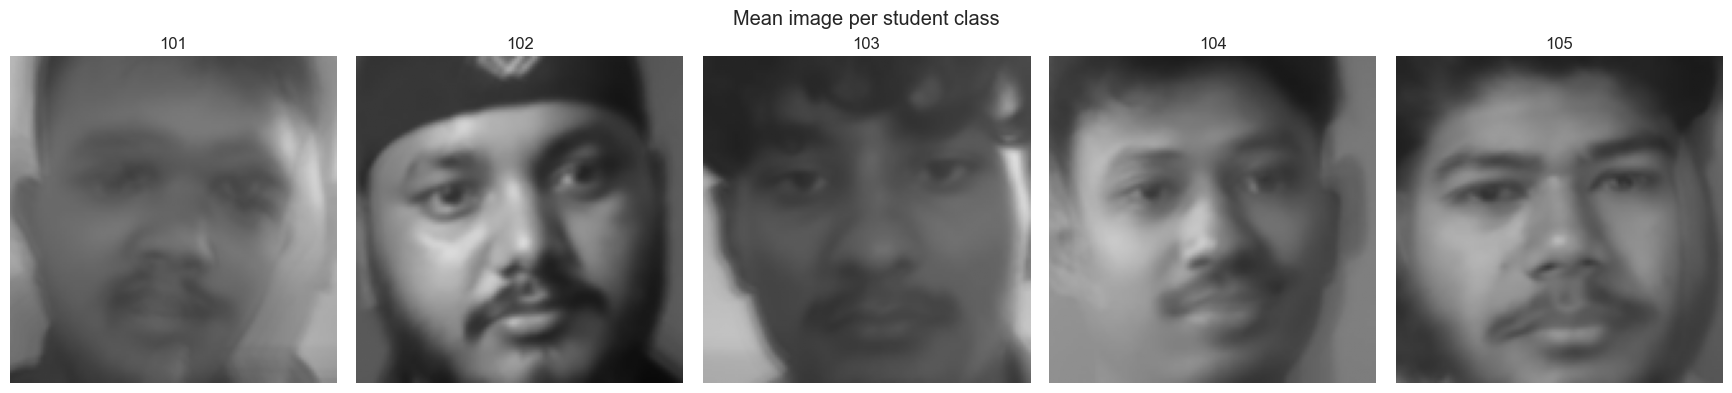

In [29]:
MEAN_IMAGE_SIZE = (128, 128)
def compute_mean_image(filepaths, size=MEAN_IMAGE_SIZE):
    arrays = []
    for filepath in filepaths:
        try:
            with Image.open(filepath) as image:
                arrays.append(np.asarray(image.convert("L").resize(size), dtype=np.float32))
        except (OSError, UnidentifiedImageError):
            continue
    return np.mean(arrays, axis=0).astype(np.uint8) if arrays else None

def show_mean_images_per_class(metadata, classes_per_batch=6):
    if metadata.empty:
        print("Mean-image analysis pending dataset collection.")
        return
    grouped = list(metadata.groupby("class_name"))
    for start in range(0, len(grouped), classes_per_batch):
        batch = grouped[start:start + classes_per_batch]
        fig, axes = plt.subplots(1, len(batch), figsize=(3.5 * len(batch), 4), squeeze=False)
        for index, (class_name, group) in enumerate(batch):
            mean_image = compute_mean_image(group["filepath"].tolist())
            if mean_image is not None:
                axes[0, index].imshow(mean_image, cmap="gray", vmin=0, vmax=255)
            else:
                axes[0, index].text(0.5, 0.5, "No readable images", ha="center", va="center")
            axes[0, index].set_title(str(class_name)); axes[0, index].axis("off")
        fig.suptitle("Mean image per student class")
        plt.tight_layout(); plt.show(); plt.close(fig)

show_mean_images_per_class(vision_df)

### Implications for Face Recognition

The Image/Vision results can guide preprocessing and model design: inconsistent dimensions may require resizing; inconsistent aspect ratios call for aspect-preserving transforms rather than uncontrolled stretching; grayscale/RGB differences require standardized channels; lighting differences may motivate brightness/contrast augmentation; low within-student variation may require more diverse collection; overly consistent backgrounds can create background shortcuts; large images may need resizing for computational efficiency; and blurry or unreadable images should be excluded or recollected. The statements above are design considerations, not claims about this dataset.


In [30]:
if valid_vision_df.empty:
    print("Face-recognition preprocessing implications are pending dataset collection.")
else:
    if valid_vision_df[["width", "height"]].nunique().max() > 1:
        print("Observed implication: image dimensions vary; resizing will be required, with aspect-preserving transforms considered.")
    if valid_vision_df["aspect_ratio"].nunique() > 1:
        print("Observed implication: aspect ratios vary; avoid uncontrolled stretching during preprocessing.")
    if valid_vision_df["channels"].nunique() > 1:
        print("Observed implication: channel counts vary; standardize all inputs to a common channel format.")
    if intensity_df.empty:
        print("No readable intensity data is available for further interpretation.")
    else:
        print("Computed intensity summaries are available above; inspect class differences before choosing normalization or augmentation.")
    print("These observations should be combined with visual inspection and capture-session metadata before changing the model pipeline.")

Computed intensity summaries are available above; inspect class differences before choosing normalization or augmentation.
These observations should be combined with visual inspection and capture-session metadata before changing the model pipeline.
